<a href="https://www.kaggle.com/code/sonawanelalitsunil/air-pollution-trends-in-china-2015-25-ml-40-17?scriptVersionId=231998318" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/air-pollution-in-china-2015-2025/air_pollution_china.csv


### Title: Air Pollution Trends in China (2015–2025)

#### Description: A brief analysis of air pollution levels in China over the past decade, highlighting key trends, policies, and improvements from 2015 to 2025.

In [2]:
df = pd.read_csv("/kaggle/input/air-pollution-in-china-2015-2025/air_pollution_china.csv")

In [3]:
df.head()

,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),CO (mg/m³),O3 (µg/m³),Temperature (°C),Humidity (%),Wind Speed (m/s),Wind Direction (°),...,Season,City,Latitude,Longitude,Day of Week,Hour,Month,Year,Weather Condition,Station ID
0,94.437337,253.533160,57.759232,3.676372,2.568404,116.383653,4.578449,43.406082,7.861799,266.338889,...,Spring,Shenzhen,36.268122,112.199251,Sunday,2,7,2016,Haze,58
1,194.174790,165.605024,75.117403,22.243199,1.528823,178.428560,37.332250,27.446097,9.742233,27.266465,...,Spring,Shanghai,48.629080,105.238302,Monday,17,11,2017,Cloudy,18
2,45.037661,24.732526,61.400657,2.309529,2.629654,156.354832,30.325762,48.364322,1.749702,258.831639,...,Autumn,Beijing,32.155184,127.648336,Sunday,6,7,2017,Fog,35
3,76.131857,78.790750,77.274046,24.302389,1.732926,81.611939,7.405654,60.582658,8.791379,306.482163,...,Summer,Shanghai,45.400785,119.615793,Monday,17,3,2020,Snow,77
4,204.127929,62.680686,99.519372,48.842644,2.687827,70.314277,6.125376,79.890364,2.395132,154.210801,...,Spring,Beijing,40.353740,99.195910,Tuesday,3,12,2020,Clear,47


In [4]:
df.tail()

,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),CO (mg/m³),O3 (µg/m³),Temperature (°C),Humidity (%),Wind Speed (m/s),Wind Direction (°),...,Season,City,Latitude,Longitude,Day of Week,Hour,Month,Year,Weather Condition,Station ID
2995,202.433868,213.848333,97.853248,20.543278,1.682403,128.810896,5.043363,86.091198,4.288590,124.457241,...,Autumn,Shanghai,22.436774,117.547069,Wednesday,17,6,2020,Haze,36
2996,216.182055,104.608468,92.595891,48.572856,0.527052,25.754024,33.054289,43.545969,3.208725,22.321887,...,Summer,Shenzhen,36.310211,114.532873,Sunday,12,11,2019,Haze,17
2997,155.490449,21.759054,7.158016,14.807278,3.043354,93.954234,11.862456,57.083113,5.814717,288.220855,...,Autumn,Shenzhen,29.709877,126.547063,Sunday,13,11,2015,Clear,1
2998,239.842895,195.061232,61.781015,15.070023,0.317404,193.777641,12.271151,98.610013,3.747732,331.660223,...,Autumn,Shanghai,40.062765,120.537238,Monday,12,9,2020,Fog,57
2999,154.983394,81.526972,33.057920,16.133852,2.682703,165.139000,8.936965,26.855408,1.375152,315.879607,...,Spring,Chengdu,40.652724,129.251611,Wednesday,18,11,2020,Fog,11


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PM2.5 (µg/m³)       3000 non-null   float64
 1   PM10 (µg/m³)        3000 non-null   float64
 2   NO2 (µg/m³)         3000 non-null   float64
 3   SO2 (µg/m³)         3000 non-null   float64
 4   CO (mg/m³)          3000 non-null   float64
 5   O3 (µg/m³)          3000 non-null   float64
 6   Temperature (°C)    3000 non-null   float64
 7   Humidity (%)        3000 non-null   float64
 8   Wind Speed (m/s)    3000 non-null   float64
 9   Wind Direction (°)  3000 non-null   float64
 10  Pressure (hPa)      3000 non-null   float64
 11  Precipitation (mm)  3000 non-null   float64
 12  Visibility (km)     3000 non-null   float64
 13  AQI                 3000 non-null   int64  
 14  Season              3000 non-null   object 
 15  City                3000 non-null   object 
 16  Latitu

In [6]:
df.describe()

,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),CO (mg/m³),O3 (µg/m³),Temperature (°C),Humidity (%),Wind Speed (m/s),Wind Direction (°),Pressure (hPa),Precipitation (mm),Visibility (km),AQI,Latitude,Longitude,Hour,Month,Year,Station ID
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,130.072742,158.818398,52.948697,25.426127,2.562514,105.613365,15.117060,54.737773,5.137389,179.396411,1014.894063,24.880798,9.900773,249.639667,35.037328,110.072445,11.289667,6.537333,2019.555333,50.164667
std,68.140050,80.915207,26.905603,14.177923,1.409570,54.054354,14.719677,26.187670,2.891444,104.076767,20.348410,14.638862,5.751453,143.396118,8.666335,11.604091,6.835057,3.441204,2.850669,28.807838
min,10.039019,20.017134,5.005047,1.014693,0.102207,10.094551,-9.997818,10.049686,0.002052,0.017217,980.020253,0.002508,0.103173,0.000000,20.005034,90.006533,0.000000,1.000000,2015.000000,1.000000
25%,72.409621,86.982912,29.885955,12.720078,1.362659,59.561719,2.123508,31.915813,2.601402,87.632382,997.419156,12.036467,4.997298,126.000000,27.495695,100.001894,5.750000,4.000000,2017.000000,26.000000
50%,128.858172,157.174723,53.404879,25.677423,2.553778,106.706302,15.334326,53.993836,5.206242,178.820576,1014.296950,24.785057,9.850522,248.000000,35.148201,110.181877,11.000000,7.000000,2020.000000,49.000000
75%,188.579931,228.603910,75.955623,37.755735,3.785613,151.293020,28.016646,77.409183,7.750817,268.835379,1032.671602,37.617215,14.808608,374.000000,42.612931,119.977826,17.000000,10.000000,2022.000000,75.000000
max,249.847473,299.702293,99.979511,49.989850,4.998658,199.936387,39.959957,99.998108,9.991277,359.881532,1049.997553,49.984126,19.998597,499.000000,49.998873,129.989284,23.000000,12.000000,2024.000000,99.000000


In [7]:
df.isnull().sum()

PM2.5 (µg/m³)         0
PM10 (µg/m³)          0
NO2 (µg/m³)           0
SO2 (µg/m³)           0
CO (mg/m³)            0
O3 (µg/m³)            0
Temperature (°C)      0
Humidity (%)          0
Wind Speed (m/s)      0
Wind Direction (°)    0
Pressure (hPa)        0
Precipitation (mm)    0
Visibility (km)       0
AQI                   0
Season                0
City                  0
Latitude              0
Longitude             0
Day of Week           0
Hour                  0
Month                 0
Year                  0
Weather Condition     0
Station ID            0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.columns

Index(['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)',
       'CO (mg/m³)', 'O3 (µg/m³)', 'Temperature (°C)', 'Humidity (%)',
       'Wind Speed (m/s)', 'Wind Direction (°)', 'Pressure (hPa)',
       'Precipitation (mm)', 'Visibility (km)', 'AQI', 'Season', 'City',
       'Latitude', 'Longitude', 'Day of Week', 'Hour', 'Month', 'Year',
       'Weather Condition', 'Station ID'],
      dtype='object')

In [10]:
df.dtypes

PM2.5 (µg/m³)         float64
PM10 (µg/m³)          float64
NO2 (µg/m³)           float64
SO2 (µg/m³)           float64
CO (mg/m³)            float64
O3 (µg/m³)            float64
Temperature (°C)      float64
Humidity (%)          float64
Wind Speed (m/s)      float64
Wind Direction (°)    float64
Pressure (hPa)        float64
Precipitation (mm)    float64
Visibility (km)       float64
AQI                     int64
Season                 object
City                   object
Latitude              float64
Longitude             float64
Day of Week            object
Hour                    int64
Month                   int64
Year                    int64
Weather Condition      object
Station ID              int64
dtype: object

In [11]:
df.shape

(3000, 24)

## Data visualizations

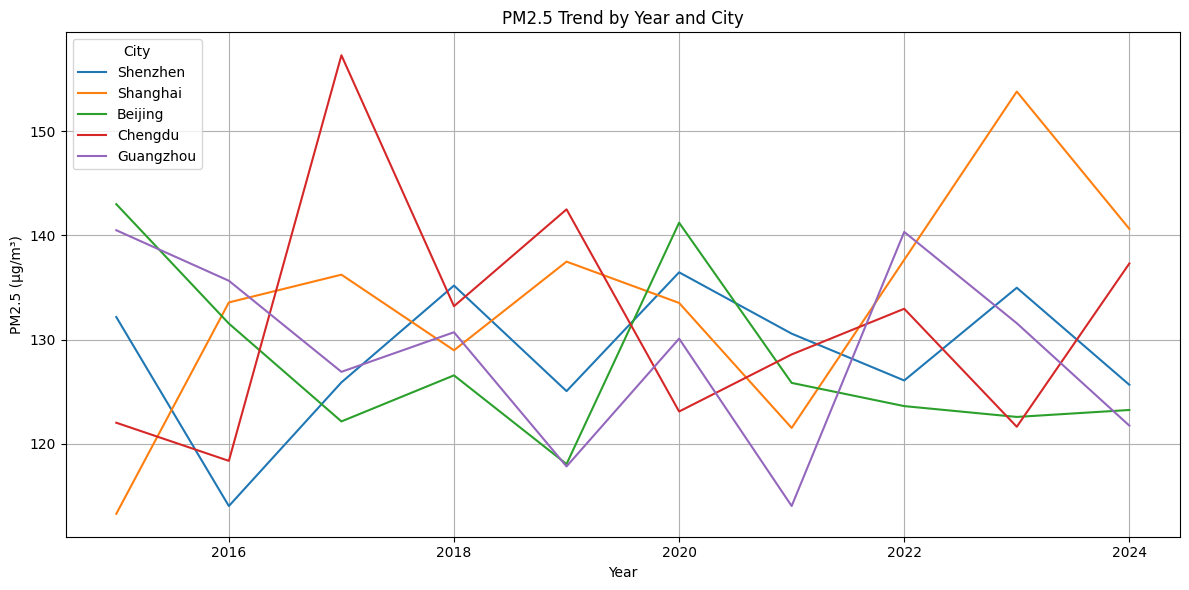

In [12]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Year', y='PM2.5 (µg/m³)', hue='City', ci=None)
plt.title('PM2.5 Trend by Year and City')
plt.ylabel('PM2.5 (µg/m³)')
plt.grid(True)
plt.tight_layout()
plt.show()

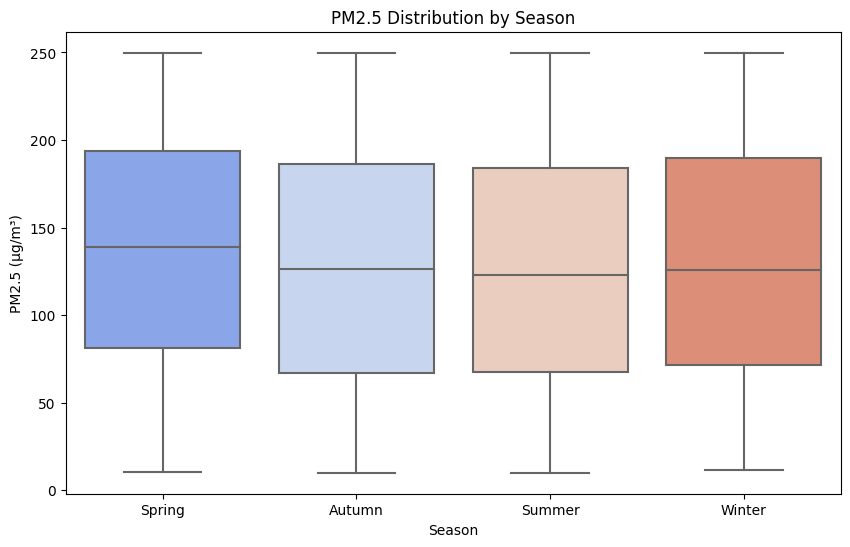

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Season', y='PM2.5 (µg/m³)', palette='coolwarm')
plt.title('PM2.5 Distribution by Season')
plt.show()

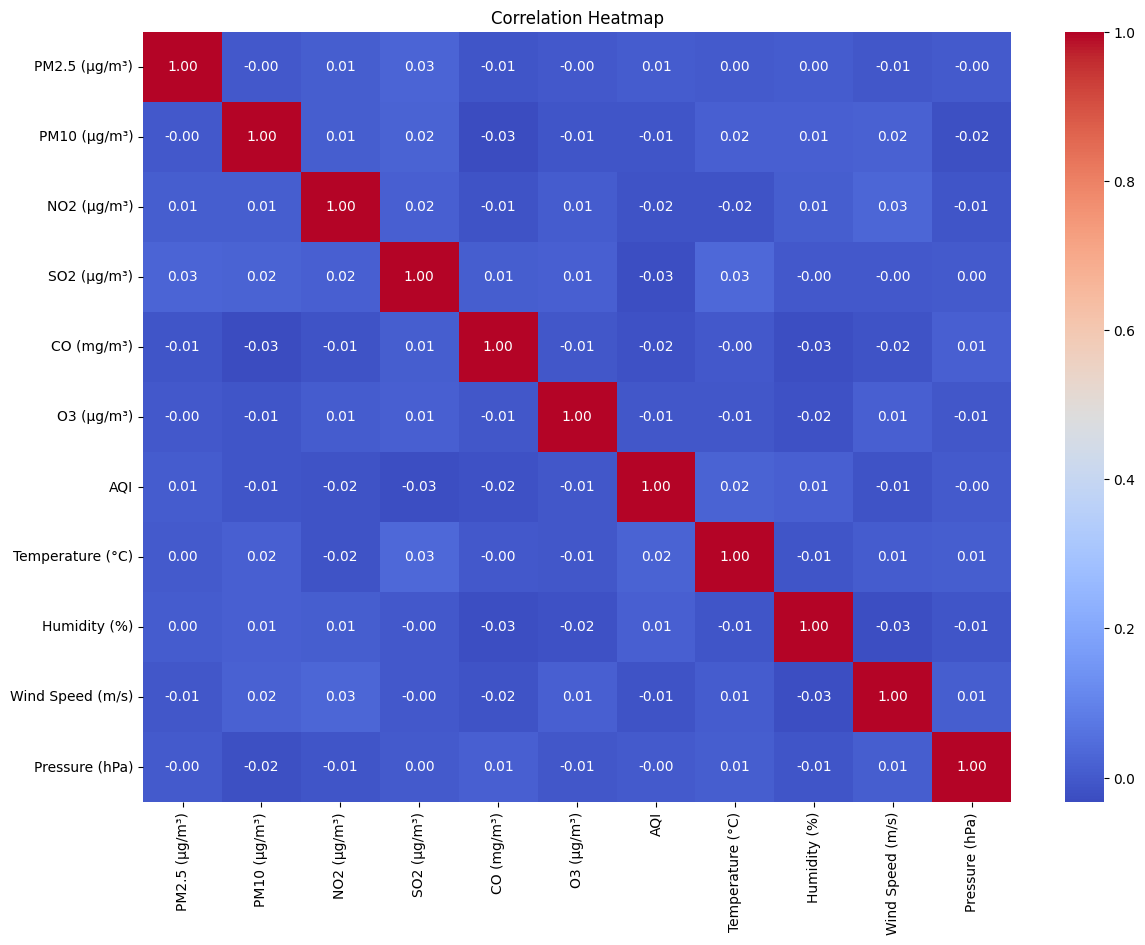

In [14]:
plt.figure(figsize=(14,10))
pollution_cols = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)',
                  'CO (mg/m³)', 'O3 (µg/m³)', 'AQI', 'Temperature (°C)',
                  'Humidity (%)', 'Wind Speed (m/s)', 'Pressure (hPa)']
sns.heatmap(df[pollution_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

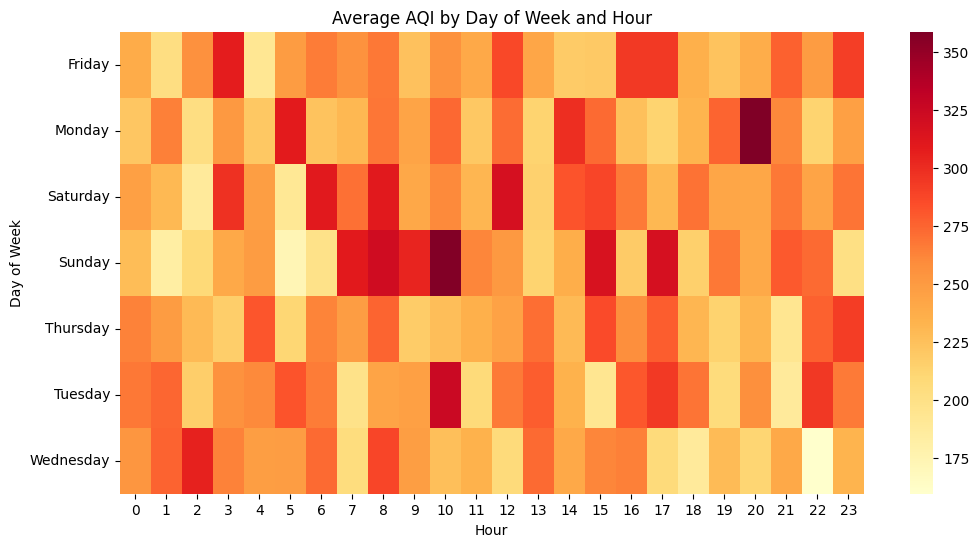

In [15]:
pivot = df.pivot_table(index='Day of Week', columns='Hour', values='AQI', aggfunc='mean')
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='YlOrRd')
plt.title('Average AQI by Day of Week and Hour')
plt.show()

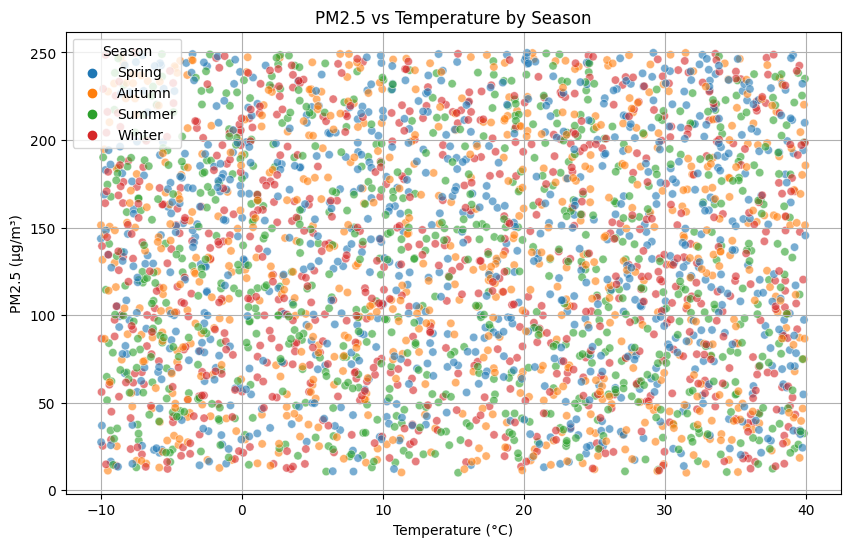

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Temperature (°C)', y='PM2.5 (µg/m³)', hue='Season', alpha=0.6)
plt.title('PM2.5 vs Temperature by Season')
plt.grid(True)
plt.show()

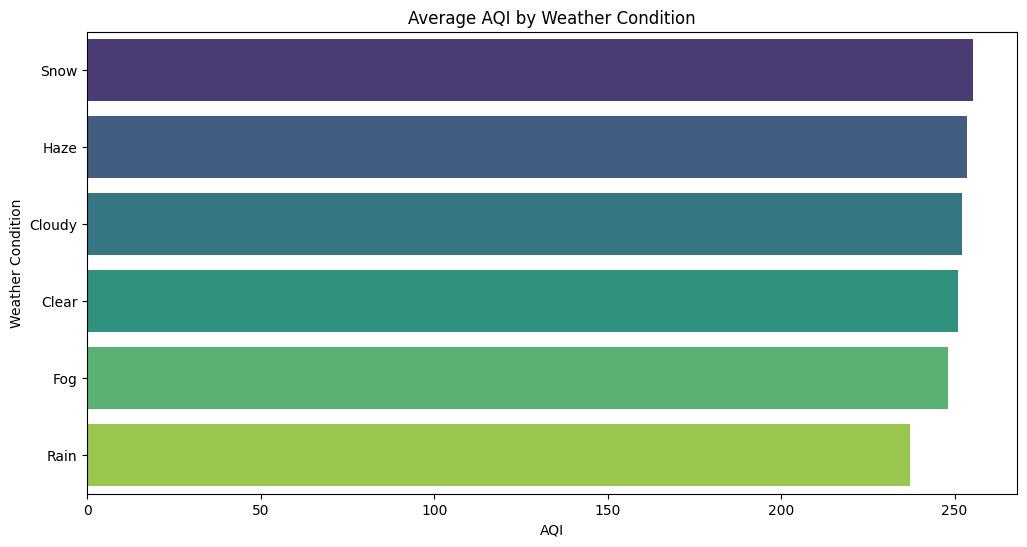

In [17]:
weather_aqi = df.groupby('Weather Condition')['AQI'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x=weather_aqi.values, y=weather_aqi.index, palette='viridis')
plt.title('Average AQI by Weather Condition')
plt.xlabel('AQI')
plt.show()

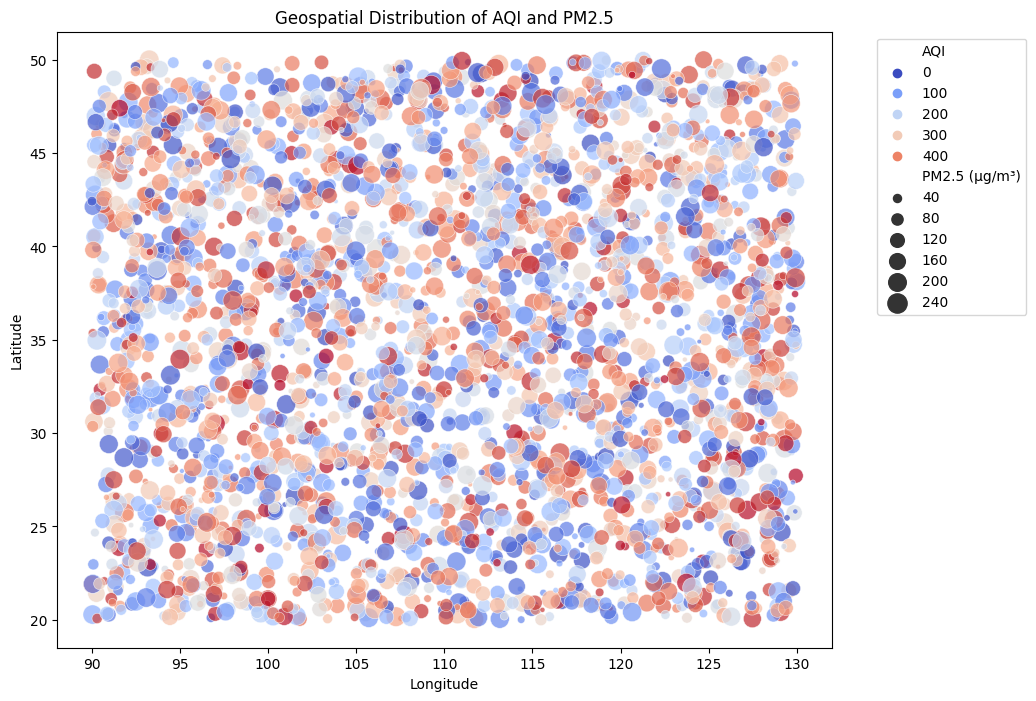

In [18]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='AQI', size='PM2.5 (µg/m³)',
                palette='coolwarm', alpha=0.7, sizes=(10, 200))
plt.title('Geospatial Distribution of AQI and PM2.5')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

## Predictive Modeling

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier


In [20]:
def aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

df['AQI_Category'] = df['AQI'].apply(aqi_category)


In [21]:
cat_cols = ['Season', 'City', 'Weather Condition', 'Day of Week']
df[cat_cols] = df[cat_cols].astype(str)

label_encoders = {}
for col in cat_cols + ['AQI_Category']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [22]:
X = df.drop(columns=['AQI', 'AQI_Category', 'Station ID'])  # drop raw AQI & Station ID
y = df['AQI_Category']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



✅ Random Forest Accuracy: 39.17%


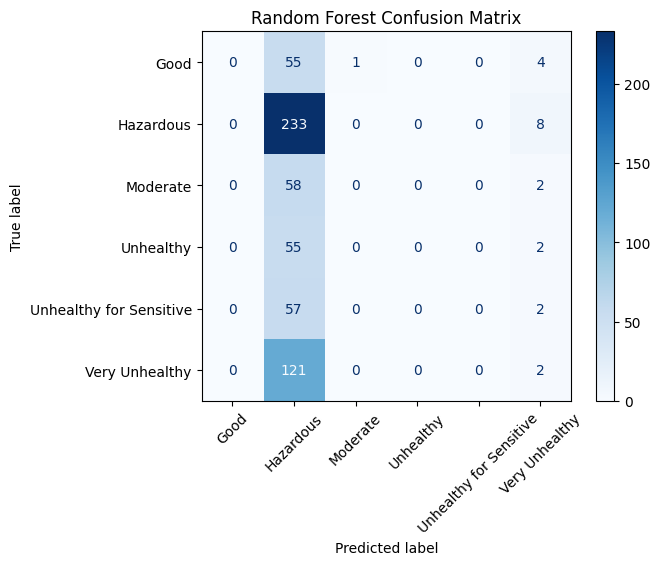


✅ Logistic Regression Accuracy: 40.17%


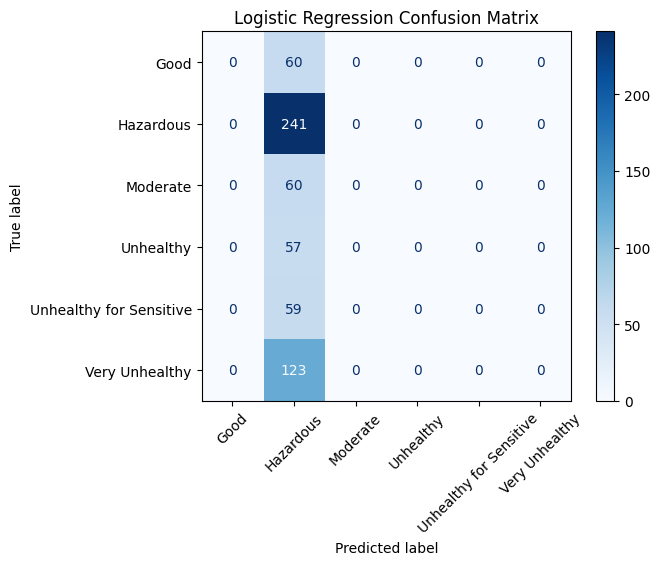


✅ Decision Tree Accuracy: 22.50%


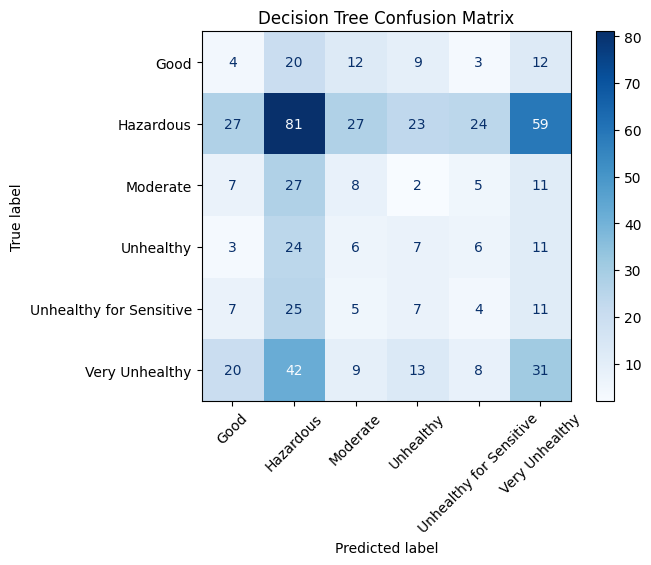


✅ SVM Accuracy: 40.17%


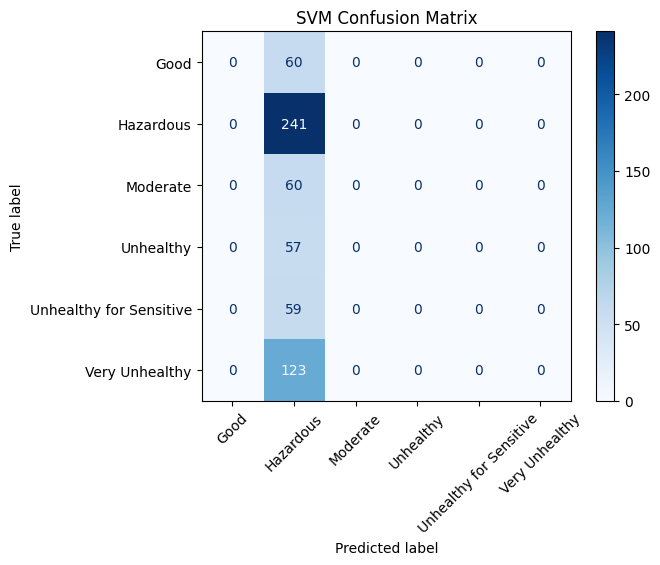


✅ Naive Bayes Accuracy: 40.17%


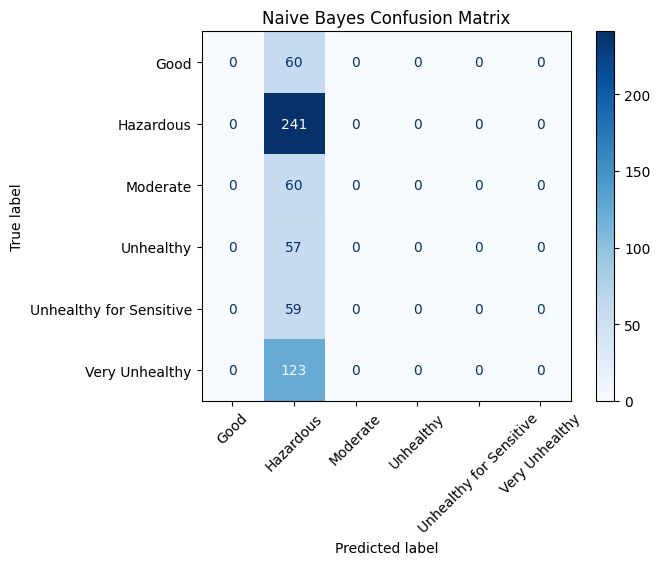


✅ KNN Accuracy: 31.67%


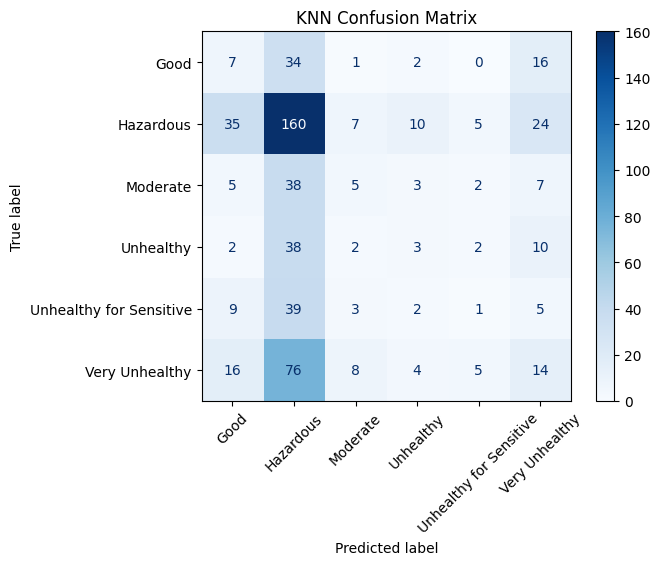

In [25]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    if name in ['Naive Bayes', 'KNN', 'SVM', 'Logistic Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = acc

    print(f"\n✅ {name} Accuracy: {acc:.2f}%")
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=label_encoders['AQI_Category'].classes_)
    disp.plot(xticks_rotation=45, cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.show()


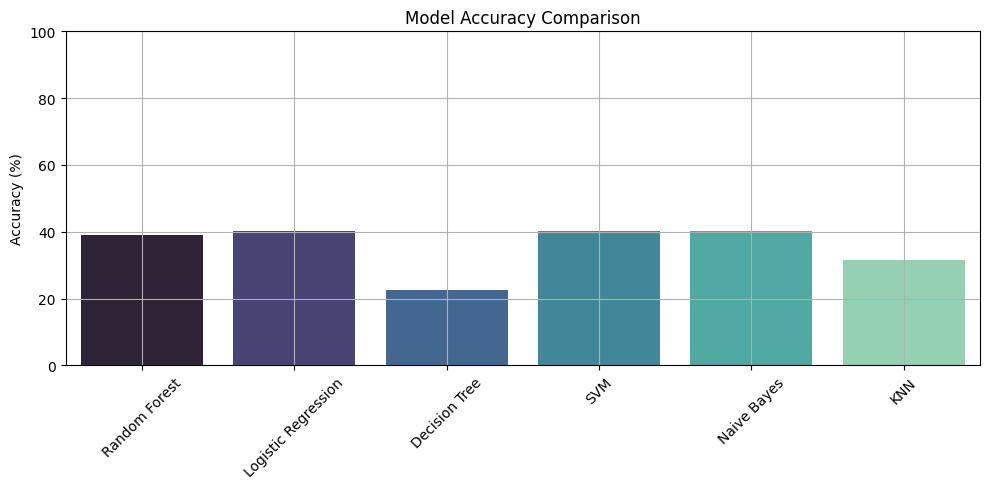

In [26]:
plt.figure(figsize=(10,5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='mako')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


## THank you ...pls upvote!!!